In [23]:
#import the necessary things
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

In [24]:
#sets the background grid
sns.set(style='whitegrid')

In [25]:
#load the csv files
fs = pd.read_csv('unrestricted_hcp_freesurfer.csv')
beh = pd.read_csv('HCP_YA_subjects_2026_06_11_12_41_53.csv')

print('FreeSurfer:', fs.shape)
print('Behavioral:', beh.shape)

FreeSurfer: (1113, 11)
Behavioral: (1206, 16)


In [26]:
beh_no_gender = beh.drop(columns=['Gender'])
df = pd.merge(fs, beh_no_gender, on='Subject', how='inner')
print('Merged:', df.shape)

Merged: (1113, 25)


In [27]:
#check for missing data
missing = df.isna().sum()
print(missing[missing > 0])
 
key_cols = [
    'FS_L_Amygdala_Vol', 'FS_R_Amygdala_Vol',
    'FS_L_Medialorbitofrontal_GrayVol', 'FS_R_Medialorbitofrontal_GrayVol',
    'FS_L_Rostralanteriorcingulate_GrayVol', 'FS_R_Rostralanteriorcingulate_GrayVol',
    'FS_L_Medialorbitofrontal_Thck', 'FS_R_Medialorbitofrontal_Thck',
    'FS_InterCranial_Vol',
    'PercStress_Unadj', 'SelfEff_Unadj', 'AngAffect_Unadj', 'AngHostil_Unadj', 'AngAggr_Unadj',
    'PercHostil_Unadj', 'PercReject_Unadj',
    'Flanker_Unadj', 'Flanker_AgeAdj', 'NEOFAC_A', 'NEOFAC_C',
    'Gender', 'Age'
]
key_cols = [c for c in key_cols if c in df.columns]
df = df.dropna(subset=key_cols).reset_index(drop=True)
print('After dropping missing:', df.shape)

AngAffect_Unadj     1
AngHostil_Unadj     1
PercHostil_Unadj    1
PercReject_Unadj    1
PercStress_Unadj    1
SelfEff_Unadj       1
NEOFAC_A            7
NEOFAC_C            7
AngAggr_Unadj       1
dtype: int64
After dropping missing: (1105, 25)


In [28]:
#change the categorical variables 
df['Gender_num'] = df['Gender'].map({'M': 0, 'F': 1})
 
# Age range -> numeric midpoint (e.g. '26-30' -> 28; '36+' -> 38 as an estimate)
def age_midpoint(age_str):
    if '+' in age_str:
        return float(age_str.replace('+', '')) + 2
    lo, hi = age_str.split('-')
    return (int(lo) + int(hi)) / 2
 
df['Age_mid'] = df['Age'].apply(age_midpoint)
print(df['Age_mid'].unique())
print('NaNs in Age_mid:', df['Age_mid'].isna().sum())
 

[28.  33.  23.5 38. ]
NaNs in Age_mid: 0


In [29]:
print(df['Gender_num'].unique())
print('NaNs in Gender_num:', df['Gender_num'].isna().sum())

print(df['Age_mid'].unique())
print('NaNs in Age_mid:', df['Age_mid'].isna().sum())

# spot-check the mapping looks right
print(df[['Gender', 'Gender_num', 'Age', 'Age_mid']].drop_duplicates())

[0 1]
NaNs in Gender_num: 0
[28.  33.  23.5 38. ]
NaNs in Age_mid: 0
    Gender  Gender_num    Age  Age_mid
0        M           0  26-30     28.0
1        F           1  26-30     28.0
2        M           0  31-35     33.0
4        F           1  31-35     33.0
5        M           0  22-25     23.5
19       F           1  22-25     23.5
24       F           1    36+     38.0
413      M           0    36+     38.0


In [30]:
#Combine bilateral brain measures + normalize for head size
# ---------------------------------------------------------
df['Amygdala_Vol'] = (df['FS_L_Amygdala_Vol'] + df['FS_R_Amygdala_Vol']) / 2
df['mOFC_GrayVol'] = (df['FS_L_Medialorbitofrontal_GrayVol'] + df['FS_R_Medialorbitofrontal_GrayVol']) / 2
df['rACC_GrayVol'] = (df['FS_L_Rostralanteriorcingulate_GrayVol'] + df['FS_R_Rostralanteriorcingulate_GrayVol']) / 2
df['mOFC_Thck'] = (df['FS_L_Medialorbitofrontal_Thck'] + df['FS_R_Medialorbitofrontal_Thck']) / 2
 
df['Amygdala_Vol_norm'] = df['Amygdala_Vol'] / df['FS_InterCranial_Vol']
df['mOFC_GrayVol_norm'] = df['mOFC_GrayVol'] / df['FS_InterCranial_Vol']
df['rACC_GrayVol_norm'] = df['rACC_GrayVol'] / df['FS_InterCranial_Vol']

In [31]:
# Sanity check: averaged values should fall between L and R
print(df[['FS_L_Amygdala_Vol','FS_R_Amygdala_Vol','Amygdala_Vol']].head())

# Summary stats - check for reasonable ranges, no NaNs/negatives
print(df[['Amygdala_Vol','mOFC_GrayVol','rACC_GrayVol','mOFC_Thck',
          'Amygdala_Vol_norm','mOFC_GrayVol_norm','rACC_GrayVol_norm']].describe())

# Check no NaNs were introduced
print(df[['Amygdala_Vol_norm','mOFC_GrayVol_norm','rACC_GrayVol_norm','mOFC_Thck']].isna().sum())

   FS_L_Amygdala_Vol  FS_R_Amygdala_Vol  Amygdala_Vol
0               1734               1994        1864.0
1               1536               1658        1597.0
2               1342               1856        1599.0
3               1848               2123        1985.5
4               1524               1277        1400.5
       Amygdala_Vol  mOFC_GrayVol  rACC_GrayVol    mOFC_Thck  \
count   1105.000000   1105.000000   1105.000000  1105.000000   
mean    1597.078281   5804.725792   2738.029412     2.653571   
std      201.127480    690.800644    498.137588     0.122901   
min     1077.500000   4180.500000   1374.000000     2.042500   
25%     1452.000000   5293.000000   2396.000000     2.568500   
50%     1581.500000   5769.000000   2678.500000     2.649500   
75%     1726.000000   6233.000000   3053.000000     2.731500   
max     2407.500000   8451.000000   4499.500000     3.125500   

       Amygdala_Vol_norm  mOFC_GrayVol_norm  rACC_GrayVol_norm  
count        1105.000000        11

In [38]:
# Define brain variables of interest (normalized for head size)
brain_vars = ['Amygdala_Vol_norm', 'mOFC_GrayVol_norm', 'rACC_GrayVol_norm', 'mOFC_Thck']

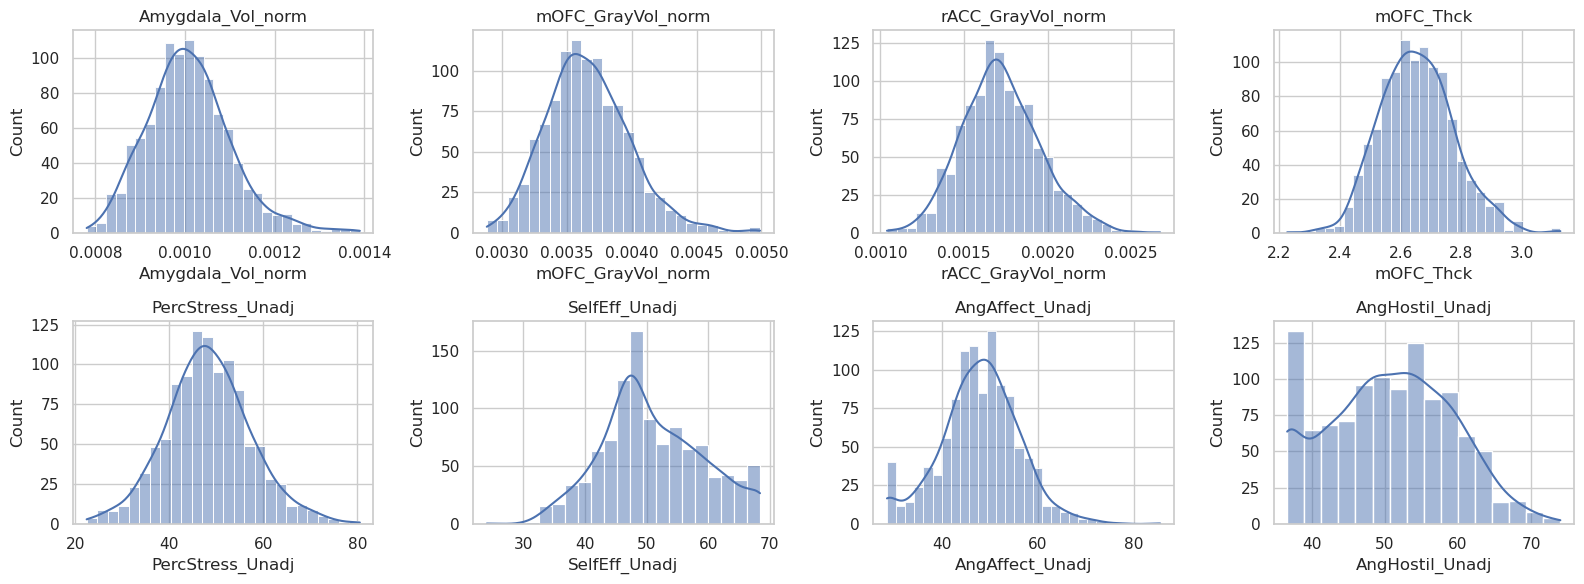

Amygdala_Vol_norm: 1 outliers (>4 SD)
mOFC_GrayVol_norm: 1 outliers (>4 SD)
rACC_GrayVol_norm: 1 outliers (>4 SD)
mOFC_Thck: 0 outliers (>4 SD)


In [39]:
# Distributions / outlier check
behav_vars = ['PercStress_Unadj', 'SelfEff_Unadj', 'AngAffect_Unadj', 'AngHostil_Unadj',
              'AngAggr_Unadj', 'PercHostil_Unadj', 'PercReject_Unadj',
              'Flanker_Unadj', 'Flanker_AgeAdj', 'NEOFAC_A', 'NEOFAC_C']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, brain_vars + behav_vars[:4]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
 
for col in brain_vars:
    z = np.abs(stats.zscore(df[col]))
    n_out = (z > 4).sum()
    print(f'{col}: {n_out} outliers (>4 SD)')
 
#drop extreme outliers:
df = df[(np.abs(stats.zscore(df[brain_vars])) < 4).all(axis=1)]
 

In [34]:
#standardise Z scores
z_cols = brain_vars + behav_vars + ['Age_mid']
for col in z_cols:
    df[col + '_z'] = stats.zscore(df[col])
 

In [35]:
#check that Zscores were calculated properly
# Check that all _z columns exist
z_cols_check = [c + '_z' for c in (brain_vars + behav_vars + ['Age_mid'])]
print(z_cols_check)
print([c in df.columns for c in z_cols_check])

# z-scored columns should have mean ~0 and std ~1
print(df[z_cols_check].describe().loc[['mean', 'std']])

# No NaNs introduced
print(df[z_cols_check].isna().sum())

# Spot-check: original vs z-scored for one variable
print(df[['PercStress_Unadj', 'PercStress_Unadj_z']].head())

['Amygdala_Vol_norm_z', 'mOFC_GrayVol_norm_z', 'rACC_GrayVol_norm_z', 'mOFC_Thck_z', 'PercStress_Unadj_z', 'SelfEff_Unadj_z', 'AngAffect_Unadj_z', 'AngHostil_Unadj_z', 'AngAggr_Unadj_z', 'PercHostil_Unadj_z', 'PercReject_Unadj_z', 'Flanker_Unadj_z', 'Flanker_AgeAdj_z', 'NEOFAC_A_z', 'NEOFAC_C_z', 'Age_mid_z']
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
      Amygdala_Vol_norm_z  mOFC_GrayVol_norm_z  rACC_GrayVol_norm_z  \
mean        -6.462462e-16         9.021203e-17        -3.411655e-16   
std          1.000462e+00         1.000462e+00         1.000462e+00   

       mOFC_Thck_z  PercStress_Unadj_z  SelfEff_Unadj_z  AngAffect_Unadj_z  \
mean -1.189159e-16       -4.461395e-16     3.821710e-16       1.730431e-16   
std   1.000462e+00        1.000462e+00     1.000462e+00       1.000462e+00   

      AngHostil_Unadj_z  AngAggr_Unadj_z  PercHostil_Unadj_z  \
mean      -5.748967e-16    -6.716696e-16       -5.773570e-16   
std        1.00

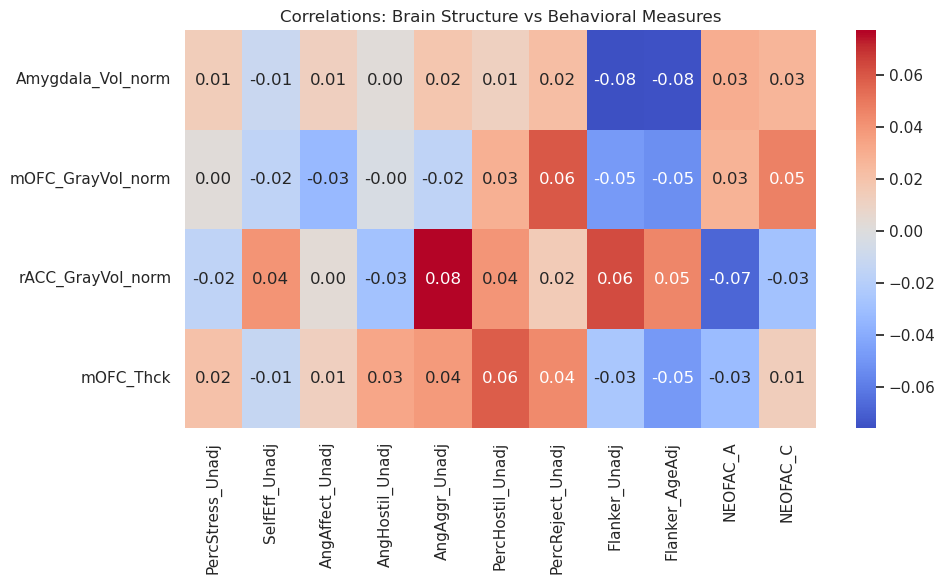

In [36]:
#correlation matrix
corr_df = df[brain_vars + behav_vars]
corr_matrix = corr_df.corr()
 
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix.loc[brain_vars, behav_vars], annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlations: Brain Structure vs Behavioral Measures')
plt.tight_layout()
plt.show()

Based on the correlation heatmap, all correlations between brain structure and behavioral measures is very weak (|r| ≤ 0.08). 

The largest are: rACC_GrayVol_norm vs AngAggr_Unadj (r ≈ 0.08), Amygdala_Vol_norm vs Flanker_Unadj/Flanker_AgeAdj (r ≈ -0.08), and rACC_GrayVol_norm vs NEOFAC_A (r ≈ -0.07).

However, with around 1100 subjects, r ≈ 0.06–0.08 — while potentially statistically significant — would explain less than 1% of variance, and likely represents a weak/null pattern that does not meaningfully explain brain-behaviour links.

In [37]:
#since there are 44 pairs we would use benjamini hochberg fdr correction
from itertools import product
from statsmodels.stats.multitest import multipletests
 
results = []
for b_var, beh_var in product(brain_vars, behav_vars):
    r, p = stats.pearsonr(df[b_var], df[beh_var])
    results.append({'brain_var': b_var, 'behav_var': beh_var, 'r': r, 'r_squared': r**2, 'p': p})
 
corr_results = pd.DataFrame(results)
 
reject, p_fdr, _, _ = multipletests(corr_results['p'], alpha=0.05, method='fdr_bh')
corr_results['p_fdr'] = p_fdr
corr_results['significant_fdr'] = reject
 
print(corr_results.sort_values('p').head(10))
print('\nNumber of pairs surviving FDR correction (q < 0.05):', corr_results['significant_fdr'].sum())

            brain_var         behav_var         r  r_squared         p  \
26  rACC_GrayVol_norm     AngAggr_Unadj  0.077344   0.005982  0.010891   
7   Amygdala_Vol_norm     Flanker_Unadj -0.075997   0.005776  0.012360   
8   Amygdala_Vol_norm    Flanker_AgeAdj -0.075195   0.005654  0.013315   
31  rACC_GrayVol_norm          NEOFAC_A -0.067680   0.004581  0.025930   
29  rACC_GrayVol_norm     Flanker_Unadj  0.063412   0.004021  0.036931   
17  mOFC_GrayVol_norm  PercReject_Unadj  0.059930   0.003592  0.048640   
38          mOFC_Thck  PercHostil_Unadj  0.058643   0.003439  0.053691   
19  mOFC_GrayVol_norm    Flanker_AgeAdj -0.053123   0.002822  0.080563   
41          mOFC_Thck    Flanker_AgeAdj -0.048940   0.002395  0.107468   
18  mOFC_GrayVol_norm     Flanker_Unadj -0.047939   0.002298  0.114862   

       p_fdr  significant_fdr  
26  0.195285            False  
7   0.195285            False  
8   0.195285            False  
31  0.285225            False  
29  0.324995            F